<a href="https://colab.research.google.com/github/KVaishali810/Gwas-Manhattan-Plot/blob/main/gwas_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

also installing the dependency ‘calibrate’




For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Libraries loaded! ✅

===== GWAS Data Summary =====
Total SNPs      : 5000 
Chromosomes     : 22 
Significant SNPs: 10 

Top 5 most significant SNPs:
      SNP CHR        BP            P
1451  rs9   7  80235688 1.464098e-10
1458 rs59   7  86462374 3.250869e-10
483  rs68   3   4249845 6.938265e-10
1443 rs85   7  72069962 7.584909e-10
655  rs49   3 201628426 1.718453e-09

Manhattan plot generated! ✅


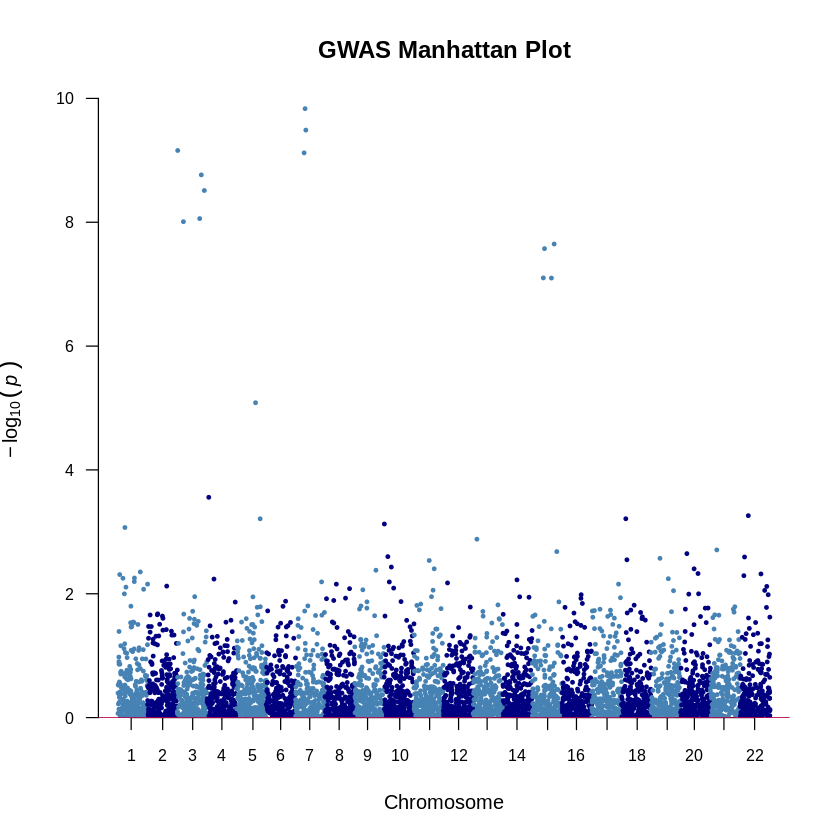

QQ plot generated! ✅

===== Quality Control =====
Lambda GC : 1.012
Interpretation: No inflation ✅


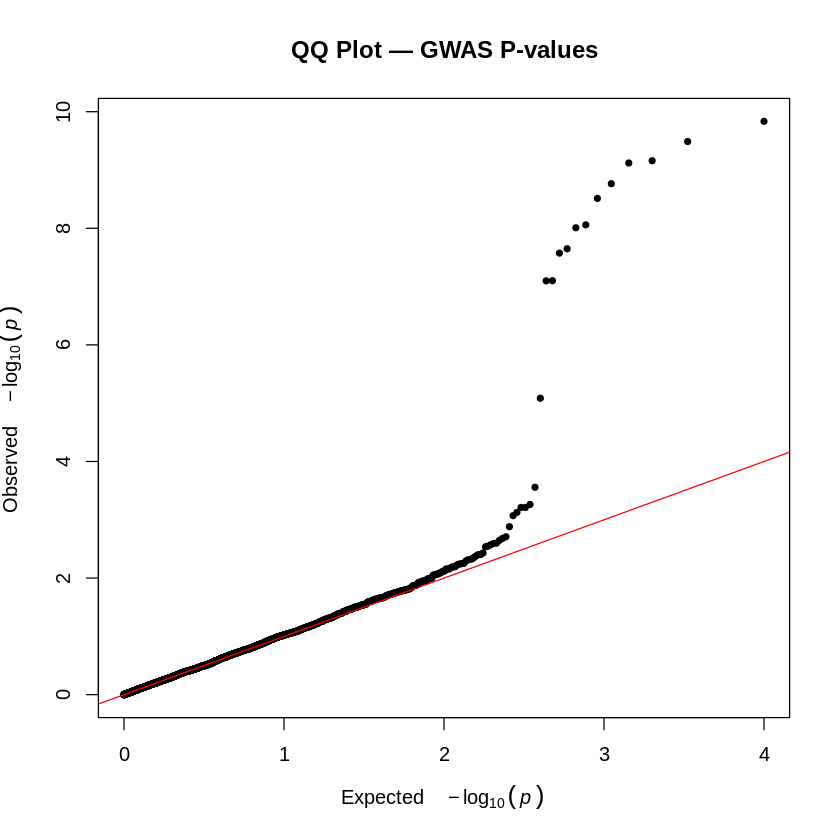

In [8]:
# ============================================
#   GWAS Manhattan & QQ Plot Generator
# ============================================

install.packages("qqman", quiet = TRUE)
install.packages("dplyr", quiet = TRUE)

library(qqman)
library(dplyr)

cat("Libraries loaded! ✅\n")

# --- simulate GWAS summary statistics ---
set.seed(42)
n_snps <- 5000

# simulate SNPs across 22 chromosomes
gwas_data <- data.frame(
    SNP = paste0("rs", 1:n_snps),
    CHR = sample(1:22, n_snps, replace = TRUE),
    BP  = sample(1:250000000, n_snps, replace = TRUE),
    P   = runif(n_snps, 0, 1)
)

# add some significant hits on chromosomes 3, 7, 15
gwas_data$P[gwas_data$CHR == 3][1:5]  <-
    runif(5, 1e-10, 1e-8)
gwas_data$P[gwas_data$CHR == 7][1:3]  <-
    runif(3, 1e-12, 1e-9)
gwas_data$P[gwas_data$CHR == 15][1:4] <-
    runif(4, 1e-9, 1e-7)

# sort by chromosome and position
gwas_data <- gwas_data %>%
    arrange(CHR, BP)

cat("\n===== GWAS Data Summary =====\n")
cat("Total SNPs      :", nrow(gwas_data), "\n")
cat("Chromosomes     :", n_distinct(gwas_data$CHR), "\n")
cat("Significant SNPs:",
    sum(gwas_data$P < 5e-8), "\n")
cat("\nTop 5 most significant SNPs:\n")
print(head(gwas_data[order(gwas_data$P), ], 5))

# --- Manhattan plot ---
manhattan(gwas_data,
          chr     = "CHR",
          bp      = "BP",
          p       = "P",
          snp     = "SNP",
          main    = "GWAS Manhattan Plot",
          suggestiveline = 1e-5,
          genomewideline = 5e-8,
          col     = c("steelblue", "navy"),
          cex     = 0.6,
          cex.axis = 0.8)

cat("\nManhattan plot generated! ✅\n")

# --- QQ plot ---
qq(gwas_data$P,
   main = "QQ Plot — GWAS P-values")

cat("QQ plot generated! ✅\n")

# --- compute lambda GC ---
chisq <- qchisq(1 - gwas_data$P, df = 1)
lambda <- median(chisq) / qchisq(0.5, df = 1)

cat("\n===== Quality Control =====\n")
cat(sprintf("Lambda GC : %.3f\n", lambda))
if (lambda < 1.05) {
    cat("Interpretation: No inflation ✅\n")
} else if (lambda < 1.10) {
    cat("Interpretation: Mild inflation ⚠️\n")
} else {
    cat("Interpretation: Significant inflation ❌\n")
}